In [1]:
from pathlib import Path

import mokapot
import pandas as pd

# Define import parameters

In [2]:
processed_dir = Path("../data/processed/spectronaut")
result_filename = "NEW_20250128_153214_FM_THIDDIAXL001_entrapment_Celegans_set1_21022025_Report_filtered_plus_fragments.tsv_annotated.csv"
library_filename = "20241219_THIDDIAXL001_spectralLibrary_Celegans_Human_entrapment_PhoX_TT_TD_DT_TT.csv"

In [3]:
# Import search results; filter for one rawfile; add decoy column
search_results = pd.read_csv(processed_dir / result_filename)
selected_rawfile = search_results["R.Raw File Name"].unique()[0]
print(f"Selected raw file: {selected_rawfile}")

search_results = search_results[search_results["R.Raw File Name"] == selected_rawfile]
search_results["Is target"] = search_results["EG.UserGroup"] != "Decoy"

C:\Users\david.hollenstein\AppData\Local\Temp\ipykernel_13640\2022985463.py:2: DtypeWarning: Columns (73) have mixed types. Specify dtype option on import or set low_memory=False.
  search_results = pd.read_csv(processed_dir / result_filename)


Selected raw file: P:/ms/Astral_1/2024/FM/DIAXL001/2024-12-18/20241218_Astral_RSLC10_TH031_Mueller_TechHub_IMP_THIDDIAXL001_Cas9_PhoX_DIAvar1_500ng_FAIMS_002.raw


## Prepare table for MokaPot

In [14]:
peptide_colum = "EG.PrecursorId"
single_peptide_column = "PP.PrecursorId"
target_column = "Is target"
score_column = "PP.PartialCscore"
spectrum_columns = ["R.Raw File Name", "PP.SourceScanID", "PP.DecoyType"]
feature_columns = ["EG.Cscore"]
single_peptide_feature_columns = [
    "PP.MatchedIons",
    "PP.TotalIons",
    "PP.RelativeMatchScore",
    "PP.PartialCscore",
]
single_peptide_coverage_columns = [
    "PP.SequenceCoverageCTerm",
    "PP.SequenceCoverageNTerm",
]

#### Only keep best entries to remove duplicates due to using a fragment table

In [10]:
search_results = search_results.sort_values("EG.Cscore", ascending=False)
best_entries = []
for group_name, group_data in search_results.groupby(spectrum_columns):
    best_entries.append(group_data.iloc[0, :])
_psm_table = pd.DataFrame(best_entries)

#### Split crosslinks into A and B peptide entries and create a combined table

In [15]:
peptide_type_tables = []
for (peptide_type, peptide_greek_type) in [("A", "Alpha"), ("B", "Beta")]:
    type_feature_columns = [f"{col}{peptide_type}" for col in single_peptide_feature_columns]
    column_mapping = dict(zip(type_feature_columns, single_peptide_feature_columns))
    for sequence_coverage_base_column in single_peptide_coverage_columns:
        type_feature_columns.append(f"{sequence_coverage_base_column}{peptide_greek_type}")
        column_mapping[f"{sequence_coverage_base_column}{peptide_greek_type}"] = sequence_coverage_base_column
    
    combined_columns = (
        [peptide_colum, target_column]
        + spectrum_columns 
        + type_feature_columns
        + feature_columns
    )
    _dipeptides = _psm_table[peptide_colum].str.split(".").str[0]
    _peptide_charge = _psm_table[peptide_colum].str.split(".").str[1]
    if peptide_type == "A":
        _single_peptide_entry = _dipeptides.str.split("_").str[0] + "." + _peptide_charge
    if peptide_type == "B":
        _single_peptide_entry = _dipeptides.str.split("_").str[1] + "." + _peptide_charge
    
    _single_peptide_table = _psm_table[combined_columns].copy()
    _single_peptide_table["PP.PrecursorId"] = _single_peptide_entry
    _single_peptide_table.rename(columns=column_mapping, inplace=True)
    _single_peptide_table["PP.PeptideType"] = peptide_type
    peptide_type_tables.append(_single_peptide_table)
single_peptide_psm_table = pd.concat(peptide_type_tables, ignore_index=True)
single_peptide_psm_table.to_clipboard()

In [16]:
# IGNORE #

# Create balanced dataset with equal numbers of target and decoy PSMs
target_psms = single_peptide_psm_table[single_peptide_psm_table[target_column]]
decoy_psms = single_peptide_psm_table[~single_peptide_psm_table[target_column]]

# Sample same number of decoys as targets
n_targets = len(target_psms)
balanced_decoys = decoy_psms.sample(n=n_targets, random_state=42)

# Concatenate targets and sampled decoys
balanced_psm_table = pd.concat([target_psms, balanced_decoys])

# Shuffle the combined dataset
balanced_single_peptide_psm_table = balanced_psm_table.sample(frac=1, random_state=42).reset_index(drop=True)

## Analyze target and decoy score distributions

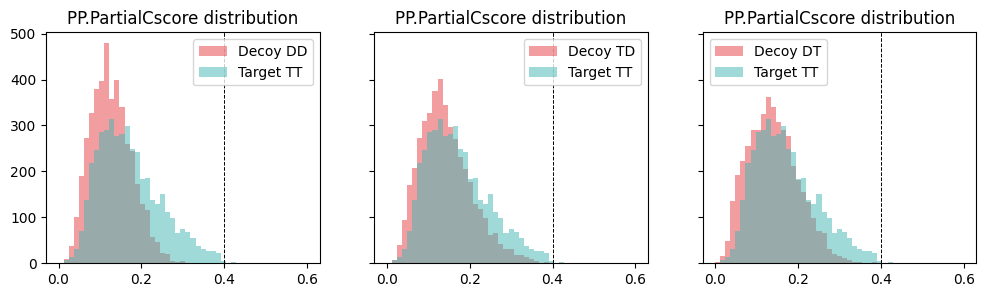

In [17]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharex=True, sharey=True)
for ax, decoy_type in zip(axes, ["DD", "TD", "DT"]):
    bins = list(np.linspace(0.0, 0.6, 50))
    decoys = single_peptide_psm_table.loc[single_peptide_psm_table["PP.DecoyType"] == decoy_type, score_column]
    targest = single_peptide_psm_table.loc[single_peptide_psm_table["PP.DecoyType"] == "TT", score_column]
    ax.hist(decoys, bins=bins, alpha=0.5, label=f"Decoy {decoy_type}", color="#E73C40")
    ax.hist(targest, bins=bins, alpha=0.5, label="Target TT", color="#40B7B5")
    ax.axvline(0.40, color="black", linestyle="--", lw=0.7)
    ax.set_title(f"{score_column} distribution")
    ax.legend()



## Run Mokapot FDR calculation

In [19]:
single_peptide_dd_tt_table = single_peptide_psm_table[single_peptide_psm_table["PP.DecoyType"].isin(["DD", "TT"])]

A mokapot.confidence.LinearConfidence object:
	- PSMs at q<=0.05: 755
	- Peptides at q<=0.05: 132



Text(0.5, 1.0, 'Multiple features')

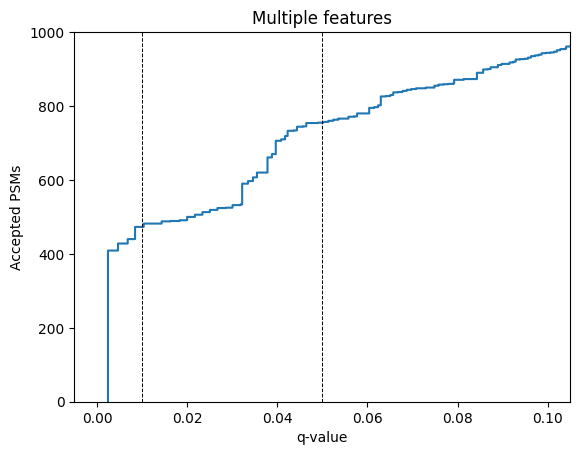

In [44]:
single_peptide_psm_dataset = mokapot.dataset.LinearPsmDataset(
    psms = single_peptide_dd_tt_table,
    target_column = target_column,
    spectrum_columns = spectrum_columns,
    peptide_column = single_peptide_column,
    feature_columns = single_peptide_feature_columns,
)
confidence, _ = mokapot.brew(single_peptide_psm_dataset, folds=3, test_fdr=0.05)
print(confidence)
ax = confidence.plot_qvalues()
ax.axvline(x=0.01, color="black", linestyle="--", lw=0.7)
ax.axvline(x=0.05, color="black", linestyle="--", lw=0.7)
ax.set_ylim(0, 1000)
ax.set_title("Multiple features")

A mokapot.confidence.LinearConfidence object:
	- PSMs at q<=0.05: 788
	- Peptides at q<=0.05: 124



Text(0.5, 1.0, 'Multiple features')

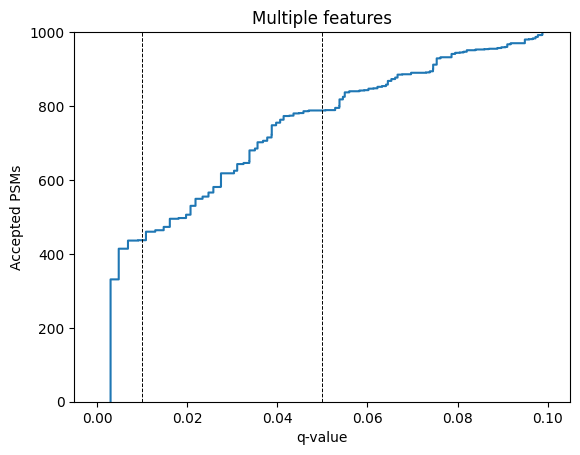

In [45]:
single_peptide_psm_dataset = mokapot.dataset.LinearPsmDataset(
    psms = single_peptide_dd_tt_table,
    target_column = target_column,
    spectrum_columns = spectrum_columns,
    peptide_column = single_peptide_column,
    feature_columns = single_peptide_feature_columns + single_peptide_coverage_columns,
)
confidence, _ = mokapot.brew(single_peptide_psm_dataset, folds=3, test_fdr=0.05)
print(confidence)
ax = confidence.plot_qvalues()
ax.axvline(x=0.01, color="black", linestyle="--", lw=0.7)
ax.axvline(x=0.05, color="black", linestyle="--", lw=0.7)
ax.set_ylim(0, 1000)
ax.set_title("Multiple features")

Error brewing confidence for PP.MatchedIons. Skipping.
Error brewing confidence for PP.TotalIons. Skipping.
Error brewing confidence for PP.RelativeMatchScore. Skipping.
A mokapot.confidence.LinearConfidence object:
	- PSMs at q<=0.05: 628
	- Peptides at q<=0.05: 116

Error brewing confidence for PP.SequenceCoverageCTerm. Skipping.
Error brewing confidence for PP.SequenceCoverageNTerm. Skipping.


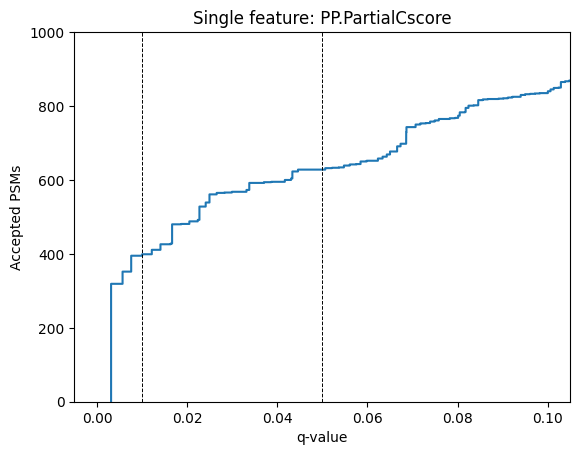

In [41]:
for score_column in single_peptide_feature_columns + single_peptide_coverage_columns:
    single_peptide_psm_dataset = mokapot.dataset.LinearPsmDataset(
        psms = single_peptide_dd_tt_table,
        target_column = target_column,
        spectrum_columns = spectrum_columns,
        peptide_column = single_peptide_column,
        feature_columns = [score_column],
    )
    try:
        confidence, _ = mokapot.brew(single_peptide_psm_dataset, folds=3, test_fdr=0.05)
    except RuntimeError:
        print(f"Error brewing confidence for {score_column}. Skipping.")
        continue        
    print(confidence)
    ax = confidence.plot_qvalues()
    ax.axvline(x=0.01, color="black", linestyle="--", lw=0.7)
    ax.axvline(x=0.05, color="black", linestyle="--", lw=0.7)
    ax.set_ylim(0, 1000)
    ax.set_title(f"Single feature: {score_column}")
